In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# General simulation

In [27]:
def vmc_simulation(N, alpha, walker_steps, ignored_walkers, d, local_energy, psi_trial, initial_positions):
    shape = np.shape(initial_positions)
    walker_positions = initial_positions
    walker_energies_sum = np.zeros(N)
    walker_energies_squared_sum = np.zeros(N)

    for step in range(walker_steps):
        proposed_new_positions = walker_positions + np.random.uniform(-d / 2, +d / 2, shape)
        probability = (psi_trial(alpha, proposed_new_positions) / psi_trial(alpha, walker_positions)) ** 2
        will_move = np.random.random(N) < probability
        walker_positions[will_move] = proposed_new_positions[will_move]
        if step >= ignored_walkers:
            e_l = local_energy(alpha, walker_positions)
            walker_energies_sum += e_l
            walker_energies_squared_sum += e_l ** 2

    e_l_expected = np.mean(walker_energies_sum / (walker_steps - ignored_walkers))
    e_l_squared_expected = np.mean(walker_energies_squared_sum) / (walker_steps - ignored_walkers)
    return e_l_expected, e_l_squared_expected - e_l_expected ** 2

# 1. Harmonic Oscillator

In [64]:
def psi_trial_ho(alpha, x):
    return np.exp(-alpha * x ** 2)


def local_energy_ho(alpha, x):
    return alpha + x ** 2 * (-2 * alpha ** 2 + 1 / 2)

alpha_values = np.arange(0.35,0.8, 0.025)
results = []
for alpha_trial in alpha_values:
    N = 400
    initial_positions = np.random.uniform(-1, 1, N)
    expected_energy, expected_variance = vmc_simulation(N=N, alpha=alpha_trial, walker_steps=30000,
                                                        ignored_walkers=4000, d=0.8, local_energy=local_energy_ho, psi_trial=psi_trial_ho, initial_positions=initial_positions)
    results.append({"Alpha": alpha_trial, "<E>": expected_energy, "<V>": expected_variance})

df_ho = pd.DataFrame(results)
df_ho

,Alpha,<E>,<V>
0,0.350,0.532367,0.066472
1,0.375,0.521453,0.042746
2,0.400,0.512312,0.025144
3,0.425,0.506596,0.013289
4,0.450,0.502893,0.005618
5,0.475,0.500650,0.001322
6,0.500,0.500000,0.000000
7,0.525,0.500688,0.001189
8,0.550,0.502160,0.004594
9,0.575,0.504972,0.009790


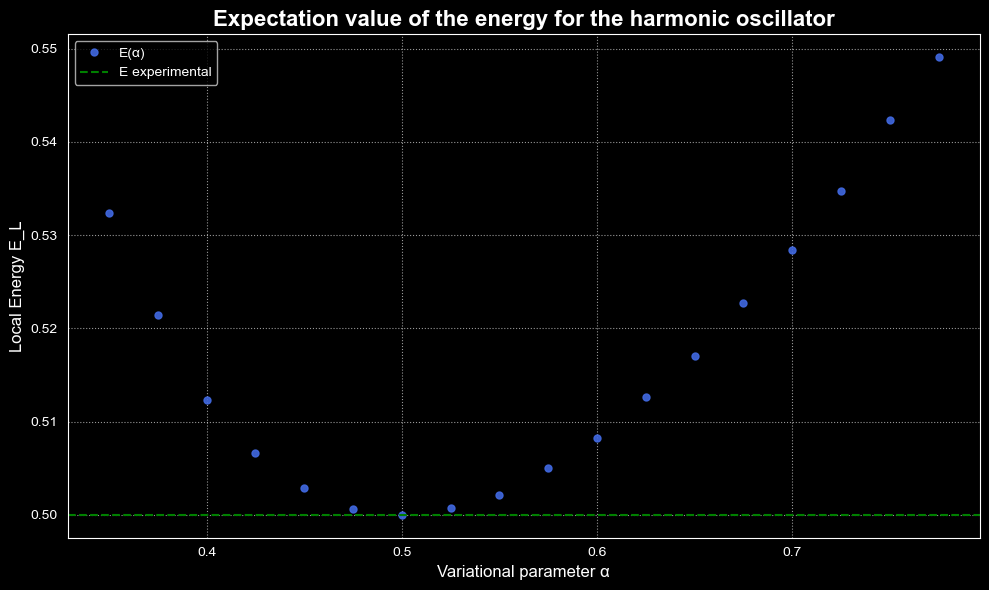

In [67]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    df_ho["Alpha"], df_ho["<E>"],
    label='E(α)',      # Label for the legend
    color='royalblue',        # Hex code or named color
    linestyle='none',           # Options: '-', '--', '-.', ':'              # Thickness of the line
    marker='o',               # Marker style (optional)
    markersize=5,             # Size of the marker
    alpha=0.9                 # Opacity (0.0 to 1.0)
)

ax.set_title("Expectation value of the energy for the harmonic oscillator", fontsize=16, fontweight='bold')
ax.set_xlabel("Variational parameter α", fontsize=12)
ax.set_ylabel("Local Energy E_L", fontsize=12)

ax.axhline(0.5, linestyle="--", color="green", label="E experimental")

ax.legend(loc='best', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 2. Hydrogen atom

Using Hamiltonian $H = -\frac{1}{2} \nabla^2 - \frac{1}{r}$

In [28]:
def psi_trial_h(alpha, x):
    r = np.linalg.norm(x, axis=1)
    return np.exp(-alpha * r)


def local_energy_h(alpha, x):
    r = np.linalg.norm(x, axis=1)
    return -1/r-1/2*alpha*(alpha-2/r)

alpha_values = [0.8, 0.9, 1.0, 1.1, 1.2]
results = []
for alpha_trial in alpha_values:
    N=400
    initial_positions = np.random.uniform(-1, 1, (N,3))
    expected_energy, expected_variance = vmc_simulation(N=400, alpha=alpha_trial, walker_steps=30000,
                                                        ignored_walkers=4000, d=0.8, psi_trial=psi_trial_h, local_energy=local_energy_h, initial_positions=initial_positions)
    results.append({"Alpha": alpha_trial, "<E>": expected_energy, "<V>": expected_variance})

df = pd.DataFrame(results)
df

,Alpha,<E>,<V>
0,0.8,-0.479966,0.026066
1,0.9,-0.494926,0.007901
2,1.0,-0.500000,0.000000
3,1.1,-0.494898,0.011895
4,1.2,-0.479877,0.059688


#  3. Helium Atom

In [32]:
def psi_trial_he(alpha, positions):
    r_1 = positions[:,0,:]
    r_2 = positions[:,1,:]
    r_12_norm = np.linalg.norm(r_1-r_2, axis=1)
    return np.exp(-2*np.linalg.norm(r_1, axis=1)) * np.exp(-2*np.linalg.norm(r_2,axis=1)) * np.exp(r_12_norm/(2*(1+alpha*r_12_norm)))

def local_energy_he(alpha, positions):
    r_1 = positions[:,0,:]
    r_2 = positions[:,1,:]
    r_12_norm = np.linalg.norm(r_1-r_2, axis=1)
    return -4+np.sum((r_1/np.linalg.norm(r_1, axis=1, keepdims=True) - r_2/np.linalg.norm(r_2,axis=1, keepdims=True)) * (r_1-r_2), axis=1) * 1/(r_12_norm *(1+alpha*r_12_norm)**2)-1/(r_12_norm*(1+alpha*r_12_norm)**3)-1/(4*(1+alpha*r_12_norm)**4) + 1/r_12_norm


alpha_values = [0.05, 0.075, 0.10, 0.125, 0.15, 0.175, 0.20, 0.25]
results = []
for alpha_trial in alpha_values:
    N = 400
    initial_positions = np.random.uniform(-0.5, 0.5, (N,2,3))
    expected_energy, expected_variance = vmc_simulation(N=N, alpha=alpha_trial, walker_steps=30000,
                                                        ignored_walkers=4000, d=1, local_energy=local_energy_he, psi_trial=psi_trial_he, initial_positions=initial_positions)
    results.append({"Alpha": alpha_trial, "<E>": expected_energy, "<V>": expected_variance})

df = pd.DataFrame(results)
df

,Alpha,<E>,<V>
0,0.050,-2.871798,0.175422
1,0.075,-2.874914,0.153403
2,0.100,-2.877189,0.136181
3,0.125,-2.878023,0.122458
4,0.150,-2.878290,0.111824
5,0.175,-2.878204,0.103357
6,0.200,-2.876851,0.096665
7,0.250,-2.874451,0.088464


## Performance profiling

In [35]:
import line_profiler

lp = line_profiler.LineProfiler(vmc_simulation)
lp.runcall(vmc_simulation, N=400, alpha=0.125, walker_steps=30000,
           ignored_walkers=4000, d=1, local_energy=local_energy_he, psi_trial=psi_trial_he, initial_positions=np.random.uniform(-0.5,0.5,(400,2,3)))
lp.print_stats()

Timer unit: 1e-09 s

Total time: 3.99684 s
File: /var/folders/jk/vyz1f6h92v17hl9dr4l3c1vc0000gn/T/ipykernel_6655/1977512633.py
Function: vmc_simulation at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def vmc_simulation(N, alpha, walker_steps, ignored_walkers, d, local_energy, psi_trial, initial_positions):
     2         1      10000.0  10000.0      0.0      shape = np.shape(initial_positions)
     3         1       1000.0   1000.0      0.0      walker_positions = initial_positions
     4         1       6000.0   6000.0      0.0      walker_energies_sum = np.zeros(N)
     5         1       2000.0   2000.0      0.0      walker_energies_squared_sum = np.zeros(N)
     6                                           
     7     30001    4203000.0    140.1      0.1      for step in range(walker_steps):
     8     30000  227634000.0   7587.8      5.7          proposed_new_positions = walker_positions + np.random.uniform(-